# 📈 Notebook 2: Análisis Exploratorio y Preparación Final

## TFM: Predicción de Estrategias de Carrera en Fórmula 1 mediante ML

**Autor:** Francisco José Moreno Bayona  
**Director:** Inmaculada Tomeo Reyes  
**Universidad:** UNIR  

---

### Objetivo de este notebook

Tomar los datasets crudos del Notebook 1 y prepararlos para entrenamiento de modelos:

1. **Análisis exploratorio (EDA):** Entender distribuciones, correlaciones y desbalance
2. **Manejo de valores faltantes:** Estrategia inteligente de imputación
3. **Normalización:** StandardScaler para redes neuronales
4. **División temporal train/test:** Sin data leakage (80/20 cronológico)
5. **Exportación:** Datasets listos para modelos

### Prerrequisito
Haber ejecutado el **Notebook 1** y que existan los archivos en `./datasets/`

## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pickle
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Directorios
DATA_DIR = Path('./datasets')
OUTPUT_DIR = Path('./datasets/prepared')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print('✅ Imports completados')

✅ Imports completados


In [2]:
# ============================================================================
# CARGAR DATASETS DEL NOTEBOOK 1
# ============================================================================

df_clasif = pd.read_csv(DATA_DIR / 'dataset_clasificacion.csv')
df_regres = pd.read_csv(DATA_DIR / 'dataset_regresion.csv')

print(f'Dataset clasificación: {df_clasif.shape}')
print(f'Dataset regresión: {df_regres.shape}')
print(f'\nColumnas clasificación:')
print(f'  {list(df_clasif.columns)}')

Dataset clasificación: (92991, 18)
Dataset regresión: (2953, 18)

Columnas clasificación:
  ['Season', 'Round', 'EventName', 'EventDate', 'Driver', 'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator', 'target_parada', 'StopLapNumber']


## 2. Análisis Exploratorio — Clasificación

### 2.1 Distribución de la variable objetivo

Evaluamos el **desbalance** entre paradas y no-paradas.
Un desbalance significativo (>80/20) requiere estrategias especiales en los modelos.

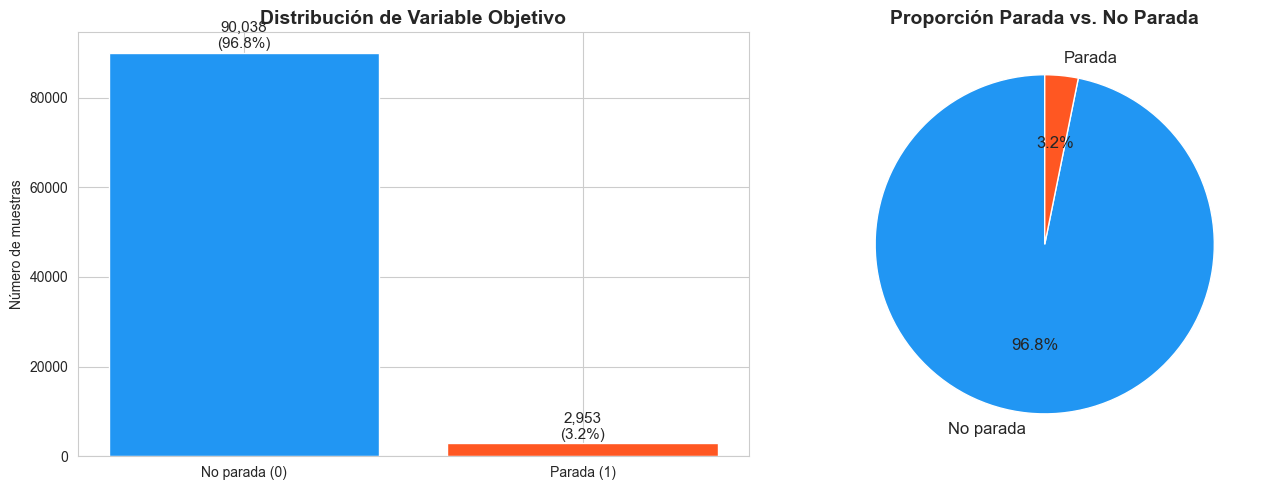


Ratio de paradas: 0.0318 (3.18%)
⚠️  DESBALANCE SIGNIFICATIVO detectado
→ Solución: class_weight="balanced" en modelos
→ Métrica primaria: F1-score (NO accuracy)


In [3]:
# ============================================================================
# DISTRIBUCIÓN DE VARIABLE OBJETIVO
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
counts = df_clasif['target_parada'].value_counts()
colors = ['#2196F3', '#FF5722']
axes[0].bar(['No parada (0)', 'Parada (1)'], counts.values, color=colors)
axes[0].set_title('Distribución de Variable Objetivo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(counts.values):
    pct = 100 * v / len(df_clasif)
    axes[0].text(i, v + len(df_clasif)*0.01, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=11)

# Gráfico circular
axes[1].pie(counts.values, labels=['No parada', 'Parada'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción Parada vs. No Parada', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico
ratio = df_clasif['target_parada'].mean()
print(f'\nRatio de paradas: {ratio:.4f} ({ratio*100:.2f}%)')
if ratio < 0.2:
    print('⚠️  DESBALANCE SIGNIFICATIVO detectado')
    print('→ Solución: class_weight="balanced" en modelos')
    print('→ Métrica primaria: F1-score (NO accuracy)')

### 2.2 Estadísticas descriptivas de features

In [4]:
# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

FEATURES_NUM = ['LapNumber', 'LapProgress', 'Position', 'TireAge',
                'StintNumber', 'LapTime_seconds', 'AvgTime_Last3',
                'DegradationIndicator']
FEATURES_BIN = ['IsHard', 'IsMedium', 'IsSoft']
FEATURES_ALL = FEATURES_NUM + FEATURES_BIN

# Solo las columnas que existan en el dataframe
FEATURES_NUM = [f for f in FEATURES_NUM if f in df_clasif.columns]
FEATURES_BIN = [f for f in FEATURES_BIN if f in df_clasif.columns]
FEATURES_ALL = FEATURES_NUM + FEATURES_BIN

print('Estadísticas de features numéricos:\n')
display(df_clasif[FEATURES_NUM].describe().round(2))

Estadísticas de features numéricos:



,LapNumber,LapProgress,Position,TireAge,StintNumber,LapTime_seconds,AvgTime_Last3,DegradationIndicator
count,92991.00,92991.00,92991.00,92991.00,92991.00,92991.00,92991.00,92991.00
mean,30.84,0.50,9.80,16.39,1.74,91.43,91.99,-0.57
std,18.07,0.28,5.42,12.18,0.67,34.23,38.96,19.54
min,1.00,0.01,1.00,1.00,1.00,67.01,67.67,-1207.06
25%,15.00,0.26,5.00,7.00,1.00,81.21,81.68,-0.26
50%,30.00,0.50,10.00,14.00,2.00,89.31,89.95,-0.02
75%,45.00,0.75,14.00,23.00,2.00,98.70,99.02,0.18
max,78.00,1.00,20.00,76.00,6.00,2526.25,2526.25,43.12


### 2.3 Correlaciones con la variable objetivo

¿Qué features tienen mayor correlación con la decisión de parar?

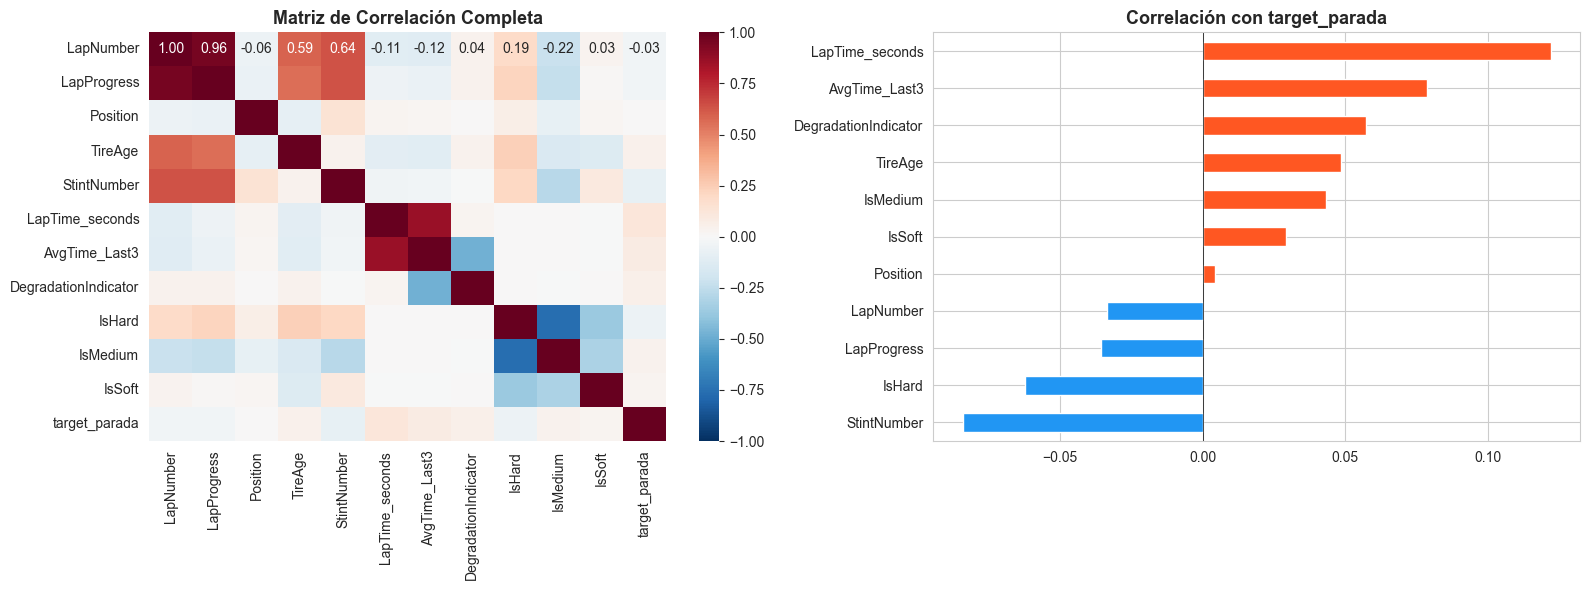


Correlaciones con target_parada (ordenadas):
  StintNumber               → -0.0842
  IsHard                    → -0.0624
  LapProgress               → -0.0357
  LapNumber                 → -0.0335
  Position                  → +0.0044
  IsSoft                    → +0.0293
  IsMedium                  → +0.0432
  TireAge                   → +0.0484
  DegradationIndicator      → +0.0573
  AvgTime_Last3             → +0.0785
  LapTime_seconds           → +0.1221


In [5]:
# ============================================================================
# MAPA DE CORRELACIONES
# ============================================================================

cols_corr = [f for f in FEATURES_ALL if f in df_clasif.columns] + ['target_parada']
corr_matrix = df_clasif[cols_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap completo
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Matriz de Correlación Completa', fontsize=13, fontweight='bold')

# Correlación con target (barras horizontales)
corr_target = corr_matrix['target_parada'].drop('target_parada').sort_values()
colors = ['#FF5722' if v > 0 else '#2196F3' for v in corr_target.values]
corr_target.plot(kind='barh', color=colors, ax=axes[1])
axes[1].set_title('Correlación con target_parada', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelaciones con target_parada (ordenadas):')
for feat, corr_val in corr_target.items():
    print(f'  {feat:25s} → {corr_val:+.4f}')

### 2.4 Distribución de features clave por clase

¿Cómo se distribuyen TireAge, Position y LapProgress cuando hay parada vs. cuando no?

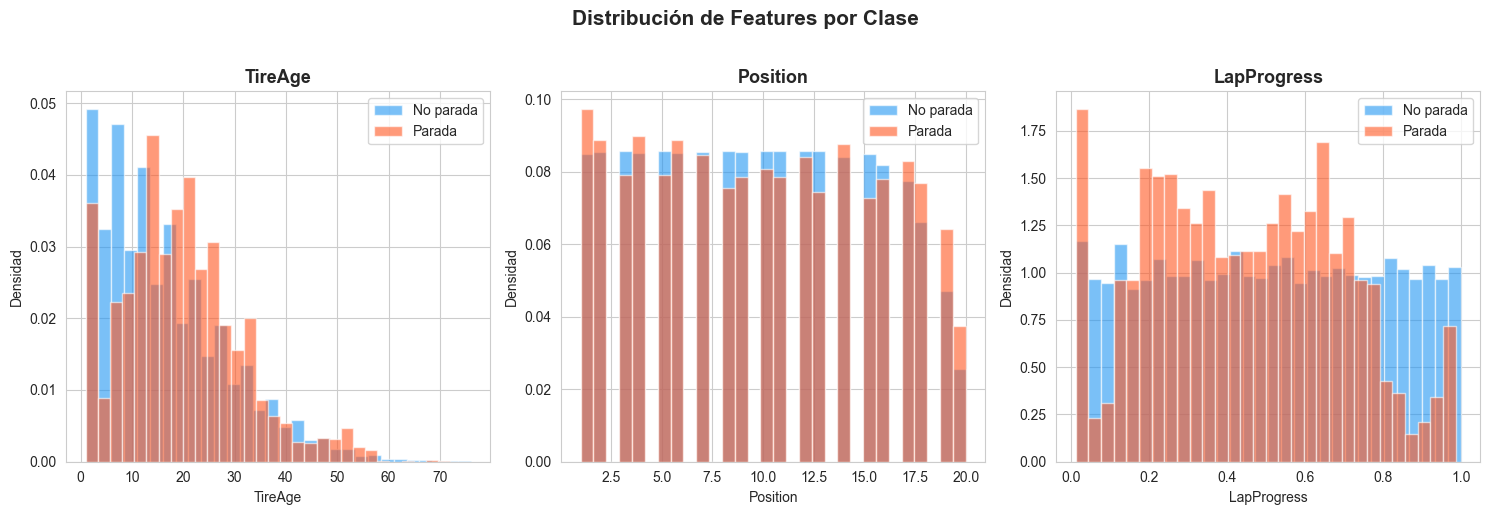

In [6]:
# ============================================================================
# DISTRIBUCIONES POR CLASE
# ============================================================================

features_plot = ['TireAge', 'Position', 'LapProgress']
features_plot = [f for f in features_plot if f in df_clasif.columns]

fig, axes = plt.subplots(1, len(features_plot), figsize=(5*len(features_plot), 5))
if len(features_plot) == 1: axes = [axes]

for i, feat in enumerate(features_plot):
    for label, color, name in [(0, '#2196F3', 'No parada'), (1, '#FF5722', 'Parada')]:
        subset = df_clasif[df_clasif['target_parada'] == label][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat, fontsize=13, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Densidad')

plt.suptitle('Distribución de Features por Clase', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_distribuciones_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis Exploratorio — Regresión

¿En qué vueltas se producen las paradas? ¿Hay patrones?

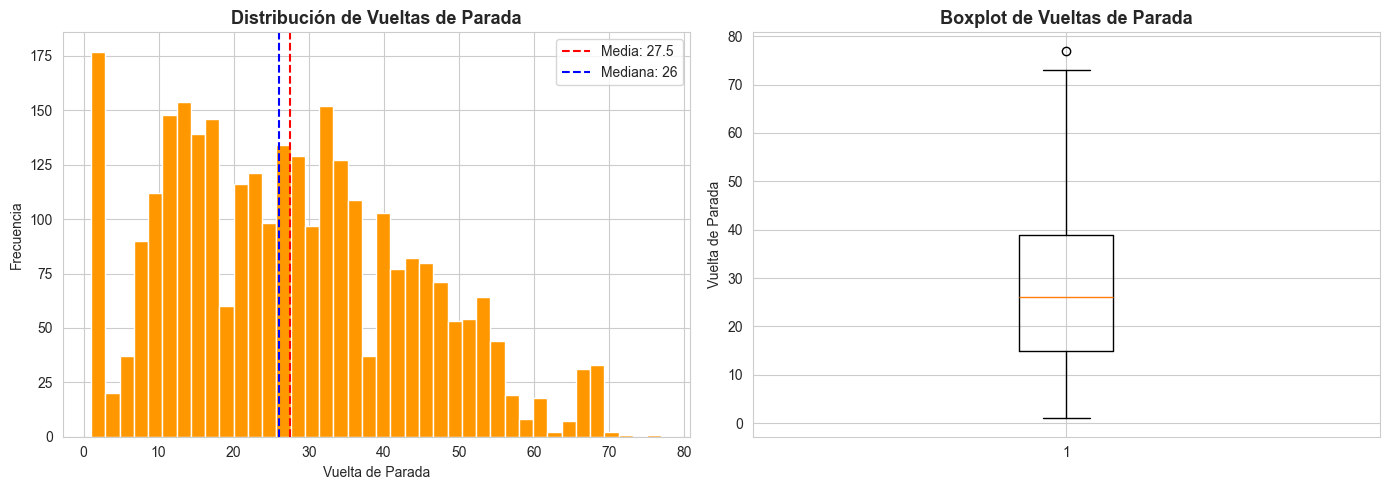

Estadísticas de vuelta de parada:
count    2953.0
mean       27.5
std        16.2
min         1.0
25%        15.0
50%        26.0
75%        39.0
max        77.0
Name: target_vuelta_parada, dtype: float64


In [7]:
# ============================================================================
# DISTRIBUCIÓN DE VUELTAS DE PARADA
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de vueltas de parada
df_regres['target_vuelta_parada'].hist(bins=40, color='#FF9800', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribución de Vueltas de Parada', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vuelta de Parada')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_regres['target_vuelta_parada'].mean(), color='red',
                linestyle='--', label=f'Media: {df_regres["target_vuelta_parada"].mean():.1f}')
axes[0].axvline(df_regres['target_vuelta_parada'].median(), color='blue',
                linestyle='--', label=f'Mediana: {df_regres["target_vuelta_parada"].median():.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_regres['target_vuelta_parada'].dropna(), vert=True)
axes[1].set_title('Boxplot de Vueltas de Parada', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Vuelta de Parada')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_regresion_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Estadísticas de vuelta de parada:')
print(df_regres['target_vuelta_parada'].describe().round(1))

## 4. Manejo de valores faltantes

**Estrategia de imputación:**

| Columna | Estrategia | Justificación |
|---------|-----------|---------------|
| Position | Forward fill + default 20 | Posición varía poco intra-vuelta |
| LapTime_seconds | Exclusión | Vuelta incompleta, no predecible |
| DegradationIndicator | Mediana por Season | Mismo comportamiento dentro de era |
| Features binarias | Sin faltantes | Derivadas de Compound (siempre presente) |

In [8]:
# ============================================================================
# DIAGNÓSTICO DE VALORES FALTANTES
# ============================================================================

print('VALORES FALTANTES - CLASIFICACIÓN')
print('-'*50)
faltantes = df_clasif[FEATURES_ALL + ['target_parada']].isnull().sum()
faltantes_pct = 100 * faltantes / len(df_clasif)

for col in faltantes.index:
    n = faltantes[col]
    pct = faltantes_pct[col]
    status = '✅' if n == 0 else '⚠️'
    print(f'  {status} {col:30s} → {n:6d} ({pct:.2f}%)')

total_faltantes = faltantes.sum()
print(f'\nTotal celdas faltantes: {total_faltantes:,}')
if total_faltantes == 0:
    print('✅ Sin valores faltantes en features críticas')
else:
    print('⚠️ Necesaria imputación')

VALORES FALTANTES - CLASIFICACIÓN
--------------------------------------------------
  ✅ LapNumber                      →      0 (0.00%)
  ✅ LapProgress                    →      0 (0.00%)
  ✅ Position                       →      0 (0.00%)
  ✅ TireAge                        →      0 (0.00%)
  ✅ StintNumber                    →      0 (0.00%)
  ✅ LapTime_seconds                →      0 (0.00%)
  ✅ AvgTime_Last3                  →      0 (0.00%)
  ✅ DegradationIndicator           →      0 (0.00%)
  ✅ IsHard                         →      0 (0.00%)
  ✅ IsMedium                       →      0 (0.00%)
  ✅ IsSoft                         →      0 (0.00%)
  ✅ target_parada                  →      0 (0.00%)

Total celdas faltantes: 0
✅ Sin valores faltantes en features críticas


In [9]:
# ============================================================================
# IMPUTACIÓN DE VALORES FALTANTES
# ============================================================================

def imputar_faltantes(df: pd.DataFrame) -> pd.DataFrame:
    """Imputa valores faltantes de forma inteligente."""
    df_proc = df.copy()
    
    # Position: forward fill + default 20
    if 'Position' in df_proc.columns:
        df_proc['Position'] = df_proc['Position'].ffill().bfill().fillna(20)
    
    # Features numéricos: mediana global
    for col in FEATURES_NUM:
        if col in df_proc.columns and df_proc[col].isnull().sum() > 0:
            mediana = df_proc[col].median()
            n_antes = df_proc[col].isnull().sum()
            df_proc[col] = df_proc[col].fillna(mediana)
            print(f'  Imputados {n_antes} valores en {col} (mediana={mediana:.2f})')
    
    return df_proc

print('Imputando clasificación...')
df_clasif_clean = imputar_faltantes(df_clasif)

print('\nImputando regresión...')
df_regres_clean = imputar_faltantes(df_regres)

# Verificar
assert df_clasif_clean[FEATURES_ALL].isnull().sum().sum() == 0, 'Aún hay faltantes!'
print('\n✅ Todos los faltantes resueltos')

Imputando clasificación...

Imputando regresión...

✅ Todos los faltantes resueltos


## 5. División temporal Train/Test

### ⚠️ Decisión CRÍTICA: NO usamos shuffle aleatorio

**Razón:** En producción, predecimos carreras **futuras** basados en datos **pasados**.
Mezclar datos temporalmente sería **data leakage** y sobreestimaría el rendimiento.

**Estrategia:** Dividimos **cronológicamente** → 80% primeras carreras para train, 20% últimas para test.

Esto es más realista y exigente para los modelos (pueden enfrentar pilotos o circuitos nuevos en test).

In [10]:
# ============================================================================
# DIVISIÓN TEMPORAL TRAIN/TEST
# ============================================================================

RATIO_TRAIN = 0.80

def dividir_temporal(df: pd.DataFrame, ratio: float = 0.80) -> tuple:
    """Divide dataset respetando orden cronológico (sin data leakage)."""
    
    # Ordenar por fecha
    df_sorted = df.sort_values('EventDate').reset_index(drop=True)
    
    # Calcular punto de corte
    n_train = int(len(df_sorted) * ratio)
    
    df_train = df_sorted.iloc[:n_train].copy()
    df_test = df_sorted.iloc[n_train:].copy()
    
    return df_train, df_test

# Dividir clasificación
train_clasif, test_clasif = dividir_temporal(df_clasif_clean, RATIO_TRAIN)

# Dividir regresión
train_regres, test_regres = dividir_temporal(df_regres_clean, RATIO_TRAIN)

# Resumen
print('CLASIFICACIÓN')
print(f'  Train: {len(train_clasif):,} muestras ({100*len(train_clasif)/len(df_clasif_clean):.0f}%)')
print(f'  Test:  {len(test_clasif):,} muestras ({100*len(test_clasif)/len(df_clasif_clean):.0f}%)')
print(f'  Train hasta: {train_clasif["EventDate"].max()}')
print(f'  Test desde:  {test_clasif["EventDate"].min()}')

print(f'\nREGRESIÓN')
print(f'  Train: {len(train_regres):,} muestras')
print(f'  Test:  {len(test_regres):,} muestras')

# Verificar sin solapamiento temporal
if train_clasif['EventDate'].max() < test_clasif['EventDate'].min():
    print(f'\n✅ Sin data leakage temporal')
else:
    print(f'\n⚠️ Posible solapamiento temporal (revisar)')

CLASIFICACIÓN
  Train: 74,392 muestras (80%)
  Test:  18,599 muestras (20%)
  Train hasta: 2025-05-18
  Test desde:  2025-05-18

REGRESIÓN
  Train: 2,362 muestras
  Test:  591 muestras

⚠️ Posible solapamiento temporal (revisar)


## 6. Normalización de features

**Decisión: StandardScaler (z-score)** → `x_norm = (x - media) / std`

**¿Por qué StandardScaler?**
- Obligatorio para **redes neuronales** (MLP, LSTM)
- Beneficioso para **SVM**
- Indiferente para árboles (pero no perjudica)

**Regla fundamental:** El scaler se ajusta **SOLO en train**, nunca en test.
Esto evita data leakage (el modelo no puede saber estadísticas del futuro).

**Features binarias (IsHard, IsMedium, IsSoft):** NO se escalan (ya son 0/1).

In [11]:
# ============================================================================
# NORMALIZACIÓN CON STANDARDSCALER
# ============================================================================

# Features a escalar (numéricos no binarios)
FEATURES_A_ESCALAR = [f for f in FEATURES_NUM if f not in FEATURES_BIN and f in train_clasif.columns]
print(f'Features a escalar: {FEATURES_A_ESCALAR}')
print(f'Features binarios (sin escalar): {FEATURES_BIN}')

# --- CLASIFICACIÓN ---
scaler_clasif = StandardScaler()

# Aprender en TRAIN (nunca en test!)
train_clasif[FEATURES_A_ESCALAR] = scaler_clasif.fit_transform(train_clasif[FEATURES_A_ESCALAR])

# Aplicar al TEST con el scaler ya aprendido
test_clasif[FEATURES_A_ESCALAR] = scaler_clasif.transform(test_clasif[FEATURES_A_ESCALAR])

# Guardar scaler
with open(OUTPUT_DIR / 'scaler_clasificacion.pkl', 'wb') as f:
    pickle.dump(scaler_clasif, f)

print('\n✅ Clasificación normalizada')
print(f'  Media post-escalado (train): {train_clasif[FEATURES_A_ESCALAR].mean().round(4).to_dict()}')

# --- REGRESIÓN ---
scaler_regres = StandardScaler()

FEATURES_A_ESCALAR_R = [f for f in FEATURES_A_ESCALAR if f in train_regres.columns]
train_regres[FEATURES_A_ESCALAR_R] = scaler_regres.fit_transform(train_regres[FEATURES_A_ESCALAR_R])
test_regres[FEATURES_A_ESCALAR_R] = scaler_regres.transform(test_regres[FEATURES_A_ESCALAR_R])

# Guardar scaler
with open(OUTPUT_DIR / 'scaler_regresion.pkl', 'wb') as f:
    pickle.dump(scaler_regres, f)

print('✅ Regresión normalizada')

Features a escalar: ['LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator']
Features binarios (sin escalar): ['IsHard', 'IsMedium', 'IsSoft']

✅ Clasificación normalizada
  Media post-escalado (train): {'LapNumber': -0.0, 'LapProgress': -0.0, 'Position': 0.0, 'TireAge': -0.0, 'StintNumber': 0.0, 'LapTime_seconds': 0.0, 'AvgTime_Last3': 0.0, 'DegradationIndicator': -0.0}
✅ Regresión normalizada


## 7. Exportar datasets finales

Guardamos los 4 datasets listos para entrenamiento de modelos.

**Archivos generados:**
- `train_clasificacion.csv` — Para entrenar modelos de clasificación
- `test_clasificacion.csv` — Para evaluar modelos de clasificación
- `train_regresion.csv` — Para entrenar modelos de regresión
- `test_regresion.csv` — Para evaluar modelos de regresión
- `scaler_clasificacion.pkl` — Para normalizar nuevos datos
- `scaler_regresion.pkl` — Para normalizar nuevos datos

In [12]:
# ============================================================================
# GUARDAR DATASETS FINALES
# ============================================================================

train_clasif.to_csv(OUTPUT_DIR / 'train_clasificacion.csv', index=False)
test_clasif.to_csv(OUTPUT_DIR / 'test_clasificacion.csv', index=False)
train_regres.to_csv(OUTPUT_DIR / 'train_regresion.csv', index=False)
test_regres.to_csv(OUTPUT_DIR / 'test_regresion.csv', index=False)

print('Archivos guardados en', OUTPUT_DIR)
print()

import os
for f in sorted(OUTPUT_DIR.glob('*')):
    size = os.path.getsize(f)
    if size > 1024*1024:
        print(f'  ✓ {f.name:40s} {size/(1024*1024):.1f} MB')
    else:
        print(f'  ✓ {f.name:40s} {size/1024:.0f} KB')

Archivos guardados en datasets\prepared

  ✓ fig_correlaciones.png                    142 KB
  ✓ fig_distribucion_target.png              74 KB
  ✓ fig_distribuciones_por_clase.png         86 KB
  ✓ fig_regresion_distribucion.png           65 KB
  ✓ scaler_clasificacion.pkl                 1 KB
  ✓ scaler_regresion.pkl                     1 KB
  ✓ test_clasificacion.csv                   3.8 MB
  ✓ test_regresion.csv                       123 KB
  ✓ train_clasificacion.csv                  15.1 MB
  ✓ train_regresion.csv                      494 KB


## 8. Resumen final y próximos pasos

In [13]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================

print('='*70)
print('RESUMEN DE PREPARACIÓN DE DATOS')
print('='*70)

print(f'\n📊 CLASIFICACIÓN (¿Parada sí/no?)')
print(f'   Train: {len(train_clasif):,} muestras')
print(f'   Test:  {len(test_clasif):,} muestras')
ratio = train_clasif['target_parada'].mean()
print(f'   Desbalance train: {ratio:.2%} positivos')
print(f'   → Usar class_weight="balanced" en modelos')
print(f'   → Métrica primaria: F1-score')

print(f'\n📈 REGRESIÓN (¿Vuelta exacta de parada?)')
print(f'   Train: {len(train_regres):,} muestras')
print(f'   Test:  {len(test_regres):,} muestras')
if 'target_vuelta_parada' in train_regres.columns:
    print(f'   Media vuelta parada: {train_regres["target_vuelta_parada"].mean():.1f}')
print(f'   → Métrica primaria: RMSE')

print(f'\n🔧 FEATURES ({len(FEATURES_ALL)})')
print(f'   Numéricos: {FEATURES_NUM}')
print(f'   Binarios:  {FEATURES_BIN}')

print(f'\n📁 ARCHIVOS en {OUTPUT_DIR}/')
print(f'   train_clasificacion.csv, test_clasificacion.csv')
print(f'   train_regresion.csv, test_regresion.csv')
print(f'   scaler_clasificacion.pkl, scaler_regresion.pkl')

print(f'\n✅ DATOS LISTOS PARA ENTRENAMIENTO DE MODELOS')
print(f'\n🎯 PRÓXIMOS PASOS:')
print(f'   1. Entrenar Decision Tree (baseline)')
print(f'   2. Entrenar Random Forest, XGBoost, LightGBM')
print(f'   3. Entrenar MLP (red neuronal)')
print(f'   4. Comparar métricas entre familias')
print(f'   5. Analizar importancia de features (SHAP)')

RESUMEN DE PREPARACIÓN DE DATOS

📊 CLASIFICACIÓN (¿Parada sí/no?)
   Train: 74,392 muestras
   Test:  18,599 muestras
   Desbalance train: 3.24% positivos
   → Usar class_weight="balanced" en modelos
   → Métrica primaria: F1-score

📈 REGRESIÓN (¿Vuelta exacta de parada?)
   Train: 2,362 muestras
   Test:  591 muestras
   Media vuelta parada: 26.0
   → Métrica primaria: RMSE

🔧 FEATURES (11)
   Numéricos: ['LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator']
   Binarios:  ['IsHard', 'IsMedium', 'IsSoft']

📁 ARCHIVOS en datasets\prepared/
   train_clasificacion.csv, test_clasificacion.csv
   train_regresion.csv, test_regresion.csv
   scaler_clasificacion.pkl, scaler_regresion.pkl

✅ DATOS LISTOS PARA ENTRENAMIENTO DE MODELOS

🎯 PRÓXIMOS PASOS:
   1. Entrenar Decision Tree (baseline)
   2. Entrenar Random Forest, XGBoost, LightGBM
   3. Entrenar MLP (red neuronal)
   4. Comparar métricas entre familias
   5. Analiza

---

### Cómo usar los datasets para entrenar modelos

```python
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

# Cargar datos
train = pd.read_csv('./datasets/prepared/train_clasificacion.csv')
test = pd.read_csv('./datasets/prepared/test_clasificacion.csv')

# Separar features y target
FEATURES = ['LapNumber', 'LapProgress', 'Position', 'TireAge',
            'StintNumber', 'IsHard', 'IsMedium', 'IsSoft',
            'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator']

X_train = train[FEATURES]
y_train = train['target_parada']
X_test = test[FEATURES]
y_test = test['target_parada']

# Entrenar modelo con compensación de desbalance
ratio_desbalance = len(y_train[y_train==0]) / len(y_train[y_train==1])
modelo = XGBClassifier(scale_pos_weight=ratio_desbalance, random_state=42)
modelo.fit(X_train, y_train)

# Evaluar
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))
print(f'F1-score: {f1_score(y_test, y_pred):.3f}')
```

---

**Fin del Notebook 2.** Continuar con entrenamiento de modelos.